In [6]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. read data
# we use OpenPyXL to read Excel files (pip install openpyxl)
df = pd.read_excel("hr_employee_data.xlsx")

# we are removing Emp_Id since it does not provide any statistical value
df = df.drop('Emp_Id', axis=1)

In [3]:
print("--- Oversight ---")
# left is 1 if they have left, 0 if they are still employed
turnover_rate = df['left'].mean() * 100
print(f"Total personalomsättning: {turnover_rate:.1f}%")
print(f"Antal anställda i datasetet: {len(df)}")
print("-" * 30)

--- Oversight ---
Total personalomsättning: 23.8%
Antal anställda i datasetet: 14999
------------------------------


In [4]:
# --- Visualizing ---
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Korrelation: Vad driver personalomsättning?')

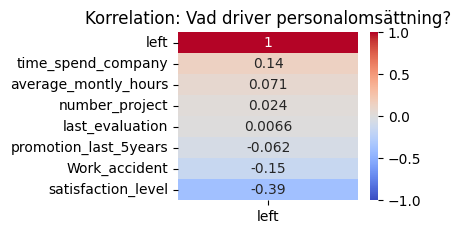

In [ ]:
# Graph 1: what correlates with employee turnover?
plt.subplot(2, 2, 1)
# we choose only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int'])
corr = numeric_df.corr()
# we look specifically at the 'left' column
sns.heatmap(corr[['left']].sort_values(by='left', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korrelation: Vad driver personalomsättning?")

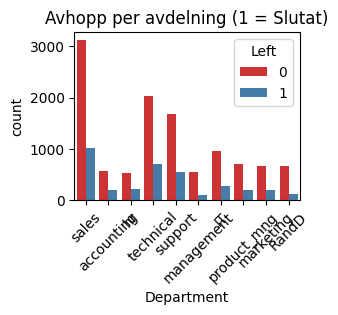

In [ ]:
# Graph: Turnover by Department
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Department', hue='left', palette='Set1')
plt.xticks(rotation=45)
plt.title("Avhopp per avdelning (1 = Slutat)")
plt.legend(title='Left')

Text(0, 0.5, 'Prestation (last_evaluation)')

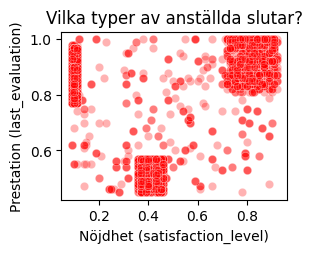

In [ ]:
# graph 3: Cluster analysis - Satisfaction vs Performance
# We look at only those who have actually left (left == 1)
plt.subplot(2, 2, 3)
sns.scatterplot(data=df[df['left']==1], 
                x='satisfaction_level', y='last_evaluation', color='red', alpha=0.3)
plt.title("Vilka typer av anställda slutar?")
plt.xlabel("Nöjdhet (satisfaction_level)")
plt.ylabel("Prestation (last_evaluation)")

Text(0.5, 1.0, 'Arbetstid vs Lön (för de som slutat vs kvar)')

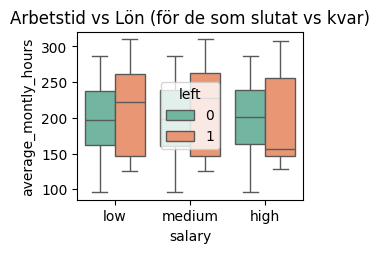

In [8]:
# Graph 4: Salary and Working Hours
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='salary', y='average_montly_hours', hue='left', palette='Set2', order=['low', 'medium', 'high'])
plt.title("Arbetstid vs Lön (för de som slutat vs kvar)")

In [14]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Deep Dive ---
print("\nStatistik (Genomsnitt) - De som slutat (1) vs Kvar (0):")
print(df.groupby('left')[['satisfaction_level', 'average_montly_hours', 'last_evaluation', 'promotion_last_5years']].mean())


Statistik (Genomsnitt) - De som slutat (1) vs Kvar (0):
      satisfaction_level  average_montly_hours  last_evaluation  \
left                                                              
0               0.666810            199.060203         0.715473   
1               0.440098            207.419210         0.718113   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  
